In [1]:
model_path = 'OpenGVLab/InternVL3-2B'
INPUT_CSV = '../labels_v2.csv'
OUTPUT_CSV = 'internvl3_2B_results.csv'

In [2]:
import pandas as pd
# Load ground truth data
df = pd.read_csv(INPUT_CSV)
print(f"Total samples in dataset: {len(df)}")
df.head()

Total samples in dataset: 452


,image_path,label,caption
0,dataset_v2/image1.jpg,no fire,The image shows a cozy living room with a fire...
1,dataset_v2/image2.jpg,no fire,The image shows a neatly arranged bedroom with...
2,dataset_v2/image3.jpg,no fire,The image shows a dining area with a wooden ta...
3,dataset_v2/image4.jpg,no fire,The image shows a modern office space with lar...
4,dataset_v2/image5.jpg,no fire,The image shows a hospital room with a patient...


In [3]:
import math
import numpy as np
import torch
import torchvision.transforms as T
from decord import VideoReader, cpu
from PIL import Image
from torchvision.transforms.functional import InterpolationMode
from transformers import AutoModel, AutoTokenizer, AutoConfig
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import time, re, json
import os


In [4]:

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def build_transform(input_size):
    MEAN, STD = IMAGENET_MEAN, IMAGENET_STD
    transform = T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=MEAN, std=STD)
    ])
    return transform

def find_closest_aspect_ratio(aspect_ratio, target_ratios, width, height, image_size):
    best_ratio_diff = float('inf')
    best_ratio = (1, 1)
    area = width * height
    for ratio in target_ratios:
        target_aspect_ratio = ratio[0] / ratio[1]
        ratio_diff = abs(aspect_ratio - target_aspect_ratio)
        if ratio_diff < best_ratio_diff:
            best_ratio_diff = ratio_diff
            best_ratio = ratio
        elif ratio_diff == best_ratio_diff:
            if area > 0.5 * image_size * image_size * ratio[0] * ratio[1]:
                best_ratio = ratio
    return best_ratio

def dynamic_preprocess(image, min_num=1, max_num=12, image_size=448, use_thumbnail=False):
    orig_width, orig_height = image.size
    aspect_ratio = orig_width / orig_height

    # calculate the existing image aspect ratio
    target_ratios = set(
        (i, j) for n in range(min_num, max_num + 1) for i in range(1, n + 1) for j in range(1, n + 1) if
        i * j <= max_num and i * j >= min_num)
    target_ratios = sorted(target_ratios, key=lambda x: x[0] * x[1])

    # find the closest aspect ratio to the target
    target_aspect_ratio = find_closest_aspect_ratio(
        aspect_ratio, target_ratios, orig_width, orig_height, image_size)

    # calculate the target width and height
    target_width = image_size * target_aspect_ratio[0]
    target_height = image_size * target_aspect_ratio[1]
    blocks = target_aspect_ratio[0] * target_aspect_ratio[1]

    # resize the image
    resized_img = image.resize((target_width, target_height))
    processed_images = []
    for i in range(blocks):
        box = (
            (i % (target_width // image_size)) * image_size,
            (i // (target_width // image_size)) * image_size,
            ((i % (target_width // image_size)) + 1) * image_size,
            ((i // (target_width // image_size)) + 1) * image_size
        )
        # split the image
        split_img = resized_img.crop(box)
        processed_images.append(split_img)
    assert len(processed_images) == blocks
    if use_thumbnail and len(processed_images) != 1:
        thumbnail_img = image.resize((image_size, image_size))
        processed_images.append(thumbnail_img)
    return processed_images

def load_image(image_file, input_size=448, max_num=12):
    image = Image.open(image_file).convert('RGB')
    transform = build_transform(input_size=input_size)
    images = dynamic_preprocess(image, image_size=input_size, use_thumbnail=True, max_num=max_num)
    pixel_values = [transform(image) for image in images]
    pixel_values = torch.stack(pixel_values)
    return pixel_values

def split_model(model_name):
    device_map = {}
    world_size = torch.cuda.device_count()
    config = AutoConfig.from_pretrained(model_path, trust_remote_code=True)
    num_layers = config.llm_config.num_hidden_layers
    # Since the first GPU will be used for ViT, treat it as half a GPU.
    num_layers_per_gpu = math.ceil(num_layers / (world_size - 0.5))
    num_layers_per_gpu = [num_layers_per_gpu] * world_size
    num_layers_per_gpu[0] = math.ceil(num_layers_per_gpu[0] * 0.5)
    layer_cnt = 0
    for i, num_layer in enumerate(num_layers_per_gpu):
        for j in range(num_layer):
            device_map[f'language_model.model.layers.{layer_cnt}'] = i
            layer_cnt += 1
    device_map['vision_model'] = 0
    device_map['mlp1'] = 0
    device_map['language_model.model.tok_embeddings'] = 0
    device_map['language_model.model.embed_tokens'] = 0
    device_map['language_model.output'] = 0
    device_map['language_model.model.norm'] = 0
    device_map['language_model.model.rotary_emb'] = 0
    device_map['language_model.lm_head'] = 0
    device_map[f'language_model.model.layers.{num_layers - 1}'] = 0

    return device_map

In [5]:
# If you set `load_in_8bit=True`, you will need two 80GB GPUs.
# If you set `load_in_8bit=False`, you will need at least three 80GB GPUs.
device_map = split_model('InternVL3-1B')
model = AutoModel.from_pretrained(
    model_path,
    torch_dtype=torch.bfloat16,
    load_in_8bit=False,
    trust_remote_code=True,
    device_map="cuda").eval()
tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True, use_fast=False)
print("Sucessfully loaded the model")


config.json: 0.00B [00:00, ?B/s]

configuration_internvl_chat.py: 0.00B [00:00, ?B/s]

configuration_intern_vit.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL3-2B:
- configuration_intern_vit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL3-2B:
- configuration_internvl_chat.py
- configuration_intern_vit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_internvl_chat.py: 0.00B [00:00, ?B/s]

...

A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL3-2B:
- conversation.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL3-2B:
- modeling_internvl_chat.py
- modeling_intern_vit.py
- conversation.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


FlashAttention2 is not installed.


/home/student4/miniconda3/lib/python3.12/site-packages/huggingface_hub/file_download.py:799: UserWarning: Not enough free disk space to download the file. The expected file size is: 4178.00 MB. The target location /home/student4/.cache/huggingface/hub/models--OpenGVLab--InternVL3-2B/blobs only has 2287.22 MB free disk space.
  warnings.warn(


model.safetensors:   0%|          | 0.00/4.18G [00:00<?, ?B/s]

KeyboardInterrupt: 

In [4]:
# generation_config = dict(max_new_tokens=2048, do_sample=True, pad_token_id=tokenizer.eos_token_id)
# def process_image(image_path):
#     """Process a single image and return the model's prediction, caption and inference time"""
#     try:
#         # Start timing
#         start_time = time.time()
        
#         # set the max number of tiles in `max_num`
#         pixel_values = load_image(image_path, max_num=12).to(torch.bfloat16).cuda()
#         prompt = (
#             "<image>\nYou are a visual analyst evaluating an image for signs of fire and the surrounding context. "
#             "Do the following tasks:\n"
#             "1: Summarize what you see in the image. Describe the environment, key objects, people, and any signs of fire or smoke.\n"
#             "2: Based on your summary, classify the fire situation: "
#             "no fire(e.g., fire alarm, fire distinguisher, fireplace with no fire burning inside..), controlled fire (e.g., fireplace with a fire burning inside, campfire, cooking, candles, match stick, lighter..) or a dangerous/uncontrolled fire (e.g., curtains on fire, smoke on ceiling, couch on fire, bed sheet on fire, spreading fire on furniture..)?\n"
#             "Return only this JSON format:\n"
#             "{ \"caption\": \"...\", \"label\": \"no fire\"|\"controlled fire\"|\"dangerous fire\" }"
#         )
#         response = model.chat(tokenizer, pixel_values, prompt, generation_config)
        
        
#         # Match the last complete JSON block
#         matches = re.findall(r'\{[^{}]+\}', response, re.DOTALL)
#         if matches:
#             try:
#                 result = json.loads(matches[-1])  # take the last match (most likely correct)
#                 caption = result.get("caption", "").strip()
#                 label = result.get("label", "").strip()
#             except Exception as e:
#                 print(f"❌ Failed to parse JSON for {image_path}: {e}")
#                 print(response)
#                 caption = response
#                 label = "unknown"
#         else:
#             print(f"❌ No JSON block found in output for {image_path}")
#             caption = response
#             label = "unknown"

#         # Calculate inference time
#         inference_time = time.time() - start_time
        
#         return label, caption, inference_time
            
#     except Exception as e:
#         print(f"Error processing {image_path}: {str(e)}")
#         return "error", "", 0.0

from lmdeploy import pipeline, TurbomindEngineConfig, ChatTemplateConfig
from lmdeploy.vl import load_image

model = 'OpenGVLab/InternVL3-2B'
pipe = pipeline(model, backend_config=TurbomindEngineConfig(session_len=16384, tp=1), chat_template_config=ChatTemplateConfig(model_name='internvl2_5'))

def process_image(image_path):
    """Process a single image and return the model's prediction, caption and inference time"""
    try:
        # Start timing
        start_time = time.time()
        
        image = load_image(image_path)
        
        prompt = (
            "<image>\nYou are a visual analyst evaluating an image for signs of fire and the surrounding context. "
            "Do the following tasks:\n"
            "1: Summarize what you see in the image. Describe the environment, key objects, people, and any signs of fire or smoke.\n"
            "2: Based on your summary, classify the fire situation: "
            "no fire(e.g., fire alarm, fire distinguisher, fireplace with no fire burning inside..), controlled fire (e.g., fireplace with a fire burning inside, campfire, cooking, candles, match stick, lighter..) or a dangerous/uncontrolled fire (e.g., curtains on fire, smoke on ceiling, couch on fire, bed sheet on fire, spreading fire on furniture..)?\n"
            "Return only this JSON format:\n"
            "{ \"caption\": \"...\", \"label\": \"no fire\"|\"controlled fire\"|\"dangerous fire\" }"
        )
        
        response = pipe((prompt, image))
        response = response.text
            
        # Match the last complete JSON block
        matches = re.findall(r'\{[^{}]+\}', response, re.DOTALL)
        if matches:
            try:
                result = json.loads(matches[-1])  # take the last match (most likely correct)
                caption = result.get("caption", "").strip()
                label = result.get("label", "").strip()
            except Exception as e:
                print(f"❌ Failed to parse JSON for {image_path}: {e}")
                print(response)
                caption = response
                label = "unknown"
        else:
            print(f"❌ No JSON block found in output for {image_path}")
            caption = response
            label = "unknown"

        # Calculate inference time
        inference_time = time.time() - start_time
        
        return label, caption, inference_time
            
    except Exception as e:
        print(f"Error processing {image_path}: {str(e)}")
        return "error", "", 0.0

Fetching 20 files:   0%|          | 0/20 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

conversation.py: 0.00B [00:00, ?B/s]

configuration_internvl_chat.py: 0.00B [00:00, ?B/s]

configuration_intern_vit.py: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

FlashAttention2 is not installed.
2025-07-11 03:59:18,058 - lmdeploy - WARNING - turbomind.py:286 - get 255 model params


[TM][WARNING] [LlamaTritonModel] `max_context_token_num` is not set, default to 16384.


2025-07-11 03:59:19,775 - lmdeploy - WARNING - tokenizer.py:499 - The token <|action_end|>, its length of indexes [27, 91, 1311, 6213, 91, 29] is over than 1. Currently, it can not be used as stop words


In [5]:
# Process all images and collect predictions
predictions = []
captions = []
inference_times = []
ground_truth = []

for idx, row in df.iterrows():
    img_path = os.path.join('../', row['image_path'])
    if os.path.exists(img_path):
        pred, caption, inf_time = process_image(img_path)
        predictions.append(pred)
        captions.append(caption)
        inference_times.append(inf_time)
        ground_truth.append(row['label'])
        if idx % 10 == 0:
            print(f"Processed {idx} images... Average inference time so far: {np.mean(inference_times):.3f}s")

print(f"\nProcessing complete! Average inference time: {np.mean(inference_times):.3f}s")

2025-07-11 03:59:19,931 - lmdeploy - WARNING - async_engine.py:657 - GenerationConfig: GenerationConfig(n=1, max_new_tokens=512, do_sample=False, top_p=1.0, top_k=50, min_p=0.0, temperature=0.8, repetition_penalty=1.0, ignore_eos=False, random_seed=None, stop_words=None, bad_words=None, stop_token_ids=[151645], bad_token_ids=None, min_new_tokens=None, skip_special_tokens=True, spaces_between_special_tokens=True, logprobs=None, response_format=None, logits_processors=None, output_logits=None, output_last_hidden_state=None, with_cache=False, preserve_cache=False, migration_request=None)
2025-07-11 03:59:19,932 - lmdeploy - WARNING - async_engine.py:658 - Since v0.6.0, lmdeploy add `do_sample` in GenerationConfig. It defaults to False, meaning greedy decoding. Please set `do_sample=True` if sampling  decoding is needed


Processed 0 images... Average inference time so far: 0.670s
Processed 10 images... Average inference time so far: 0.463s
Processed 20 images... Average inference time so far: 0.439s
Processed 30 images... Average inference time so far: 0.438s
Processed 40 images... Average inference time so far: 0.433s
Processed 50 images... Average inference time so far: 0.436s
Processed 60 images... Average inference time so far: 0.435s
Processed 70 images... Average inference time so far: 0.431s
Processed 80 images... Average inference time so far: 0.431s
❌ Failed to parse JSON for ../dataset_v2/image86.jpg: Expecting ',' delimiter: line 3 column 3 (char 286)
```json
{
  "caption": "The image shows a room with two beds, a small table, and various items scattered around. There are shelves on the right side and a window letting in natural light. No visible signs of fire or smoke, and no fire distinguishers such as candles, matchsticks, or flames."
  "label": "no fire"
}
```
Processed 90 images... Aver

In [ ]:
# Save results to CSV
results_df = pd.DataFrame({
    'image_path': df['image_path'],
    'true_label': ground_truth,
    'predicted_label': predictions,
    'caption': captions,
    'inference_time': inference_times,
    'correct': [t == p for t, p in zip(ground_truth, predictions)]
})

results_df.to_csv(OUTPUT_CSV, index=False)
print(f"Results saved to {OUTPUT_CSV}")

Results saved to internvl3_2B_results.csv


Results saved to internvl3_2B_results.csv


In [11]:
# Load the CSV file
df = pd.read_csv(OUTPUT_CSV)
df = df.dropna(subset=['true_label', 'predicted_label', 'inference_time'])  # Remove rows with missing values

# Extract relevant columns
ground_truth = df['true_label'].astype(str).str.strip()
predictions = df['predicted_label'].astype(str).str.strip()
inference_times = df['inference_time'].astype(float)

# Calculate classification metrics
accuracy = accuracy_score(ground_truth, predictions)
precision, recall, f1, _ = precision_recall_fscore_support(
    ground_truth, predictions, average='weighted'
)

# Print performance metrics
print("Model Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Inference time stats
print("\nInference Time Statistics:")
print(f"Average: {np.mean(inference_times):.3f}s")
print(f"Std Dev: {np.std(inference_times):.3f}s")
print(f"Min: {np.min(inference_times):.3f}s")
print(f"Max: {np.max(inference_times):.3f}s")

Model Performance Metrics:
Accuracy: 0.9358
Precision: 0.9353
Recall: 0.9358
F1 Score: 0.9350

Inference Time Statistics:
Average: 0.520s
Std Dev: 0.177s
Min: 0.241s
Max: 1.088s


/home/student4/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


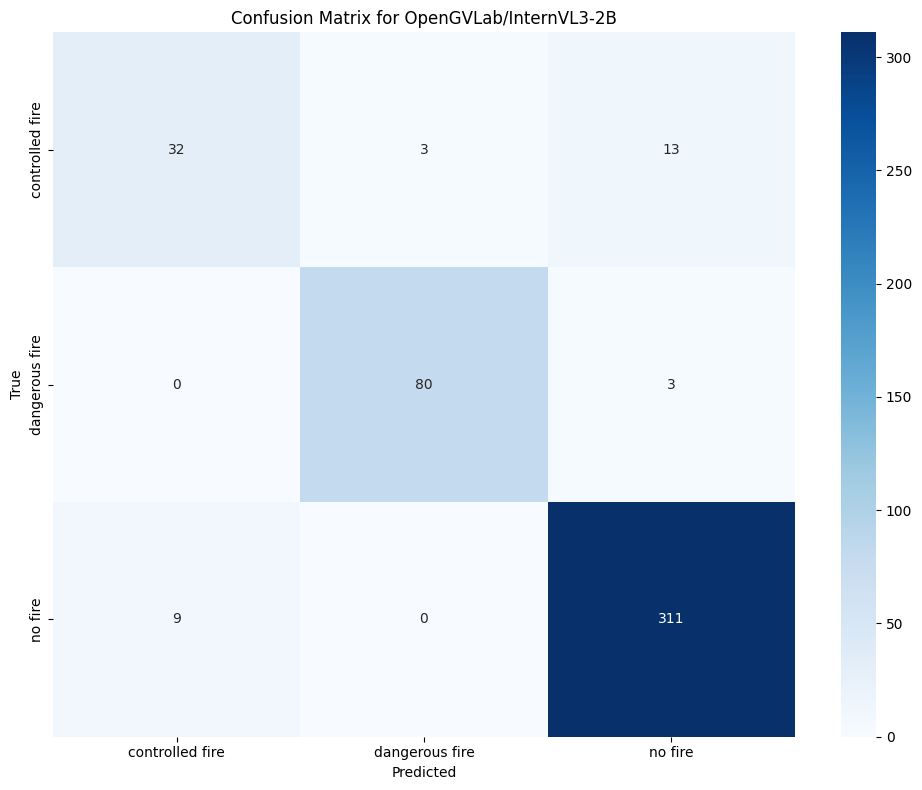

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
# Confusion matrix
labels = sorted(df['true_label'].unique())
cm = confusion_matrix(ground_truth, predictions, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.title(f'Confusion Matrix for {model_path}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()